<a href="https://colab.research.google.com/github/Maks04092002/IS484-Lab001-Jueves-Tanta/blob/main/Ejercicio3_Inspeccion_Tanta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz NumPy de $5 \times 5$ píxeles ($0 = \text{normal}$, $1 = \text{defectuoso}$). |
| **Acciones (A)** | Aprobar, enviar a revisión manual, rechazar. |
| **Entorno (E)** | Cámara industrial integrada en la banda transportadora de producción. |
| **Objetivo** | Filtrar productos defectuosos automáticamente antes del empaquetado final. |
| **Medida de desempeño (P)** | Precisión en la detección de defectos y minimización de descartes erróneos. |

### Justificación de las reglas
Las reglas garantizan el control de calidad sin detener innecesariamente la línea:
Un producto con 0 defectos se aprueba inmediatamente para mantener el flujo continuo.
La presencia de 1 a 3 píxeles defectuosos representa un fallo menor reparable por un operario en revisión manual, evitando desechar la pieza.
Detectar más de 3 defectos indica una falla estructural crítica irrecuperable, requiriendo el rechazo total del producto.

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    defectos = np.sum(imagen == 1)

    if defectos == 0:
        return ("aprobar", f"Producto perfecto ({defectos} defectos).")
    elif defectos <= 3:
        return ("revisión manual", f"Defectos menores detectados ({defectos} píxeles). Requiere inspección humana.")
    else:
        return ("rechazar", f"Fallo crítico de calidad ({defectos} píxeles defectuosos).")

--- RESULTADOS DE INSPECCIÓN VISUAL ---
Prueba 'Sin defectos': [APROBAR] - Producto perfecto (0 defectos).
Prueba '1 defecto': [REVISIÓN MANUAL] - Defectos menores detectados (1 píxeles). Requiere inspección humana.
Prueba 'Límite (3 defectos)': [REVISIÓN MANUAL] - Defectos menores detectados (3 píxeles). Requiere inspección humana.
Prueba 'Rechazo (5 defectos)': [RECHAZAR] - Fallo crítico de calidad (5 píxeles defectuosos).


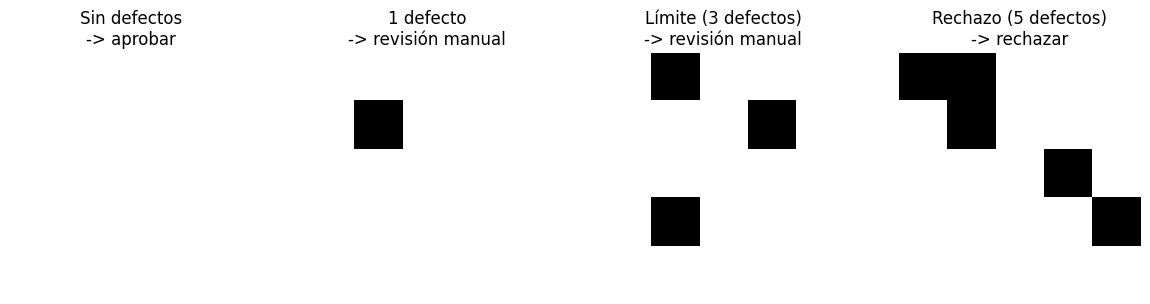

In [2]:
import matplotlib.pyplot as plt

# Definición de 4 matrices de prueba (incluye 0 defectos, caso límite y rechazo)
img_sin_defectos = np.zeros((5, 5), dtype=int)

img_un_defecto = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

img_limite_3 = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0]
])  # Exactamente 3 defectos (caso límite)

img_rechazo_5 = np.array([
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0]
])  # 5 defectos (>3)

pruebas = [
    ("Sin defectos", img_sin_defectos),
    ("1 defecto", img_un_defecto),
    ("Límite (3 defectos)", img_limite_3),
    ("Rechazo (5 defectos)", img_rechazo_5)
]

print("--- RESULTADOS DE INSPECCIÓN VISUAL ---")
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for idx, (nombre, img) in enumerate(pruebas):
    accion, motivo = agente_inspeccion(img)
    print(f"Prueba '{nombre}': [{accion.upper()}] - {motivo}")

    # Visualización gráfica de la matriz
    axes[idx].imshow(img, cmap="gray_r")
    axes[idx].set_title(f"{nombre}\n-> {accion}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()